In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

In [4]:
df=pd.read_csv("data/Travel.csv")
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [5]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [6]:
df.Gender.value_counts()

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

In [7]:
df.MaritalStatus.value_counts()

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

In [8]:
df["Gender"]=df["Gender"].replace("Fe Male","Female")
df["MaritalStatus"]=df["MaritalStatus"].replace("Single","Unmarried")

In Pandas, df.isnull().mean() is commonly used to find the percentage of missing

df.isnull() → converts the dataframe into True / False values

True = missing value

False = not missing

mean() → in Python, True = 1 and False = 0
So the mean gives the fraction of missing values.

In [9]:
features_na=[feature for feature in df.columns if df[feature].isnull().sum()>0]
for feature in features_na:
    print(f'{feature} has {np.round(df[feature].isnull().mean()*100,5)} % missing values')

Age has 4.62357 % missing values
TypeofContact has 0.51146 % missing values
DurationOfPitch has 5.13502 % missing values
NumberOfFollowups has 0.92062 % missing values
PreferredPropertyStar has 0.53191 % missing values
NumberOfTrips has 2.86416 % missing values
NumberOfChildrenVisiting has 1.35025 % missing values
MonthlyIncome has 4.76678 % missing values


### Imputing null values

In [10]:
#df.select_dtypes(include=['int64','float64'])
#df.select_dtypes(include=None, exclude=None)
df[features_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


In [11]:
df.NumberOfChildrenVisiting.mode()

0    1.0
Name: NumberOfChildrenVisiting, dtype: float64

In [12]:
df.Age.fillna(df.Age.median(),inplace=True)
df.TypeofContact.fillna(df.TypeofContact.mode()[0],inplace=True)
df.DurationOfPitch.fillna(df.DurationOfPitch.median(),inplace=True)
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0],inplace=True)
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0],inplace=True)
df.NumberOfTrips.fillna(df.NumberOfTrips.mean(),inplace=True)
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0],inplace=True)
df.MonthlyIncome.fillna(df.MonthlyIncome.median(),inplace=True)
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [13]:
df.drop("CustomerID",inplace=True,axis=1)

In [14]:
## combining  NumberOfChildrenVisiting   + NumberOfPersonVisiting      

df["Total Visiting"]=df.NumberOfPersonVisiting+df.NumberOfChildrenVisiting
df.drop(columns=["NumberOfPersonVisiting","NumberOfChildrenVisiting"],axis=1)

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,Total Visiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,Manager,26576.0,4.0
4884,1,28.0,Company Invited,1,31.0,Salaried,Male,5.0,Basic,3.0,Unmarried,3.0,1,3,1,Executive,21212.0,6.0
4885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4.0,Standard,4.0,Married,7.0,0,1,1,Senior Manager,31820.0,7.0
4886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,4.0,Basic,3.0,Unmarried,3.0,0,5,0,Executive,20289.0,5.0


In [15]:
#Get All Nummerical Features
numericalFeatures=[feature for feature in df.columns if df[feature].dtype!='o']
numericalFeatures

['ProdTaken',
 'Age',
 'TypeofContact',
 'CityTier',
 'DurationOfPitch',
 'Occupation',
 'Gender',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'ProductPitched',
 'PreferredPropertyStar',
 'MaritalStatus',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'Designation',
 'MonthlyIncome',
 'Total Visiting']

In [16]:
#Get All Object Features
categoricalFeature=[feature for feature in df.columns if df[feature].dtype=='o']
categoricalFeature

[]

In [17]:
#Get All Descrete Features
descreteFeature=[feature for feature in numericalFeatures if len(df[feature].unique())<15]
descreteFeature

['ProdTaken',
 'TypeofContact',
 'CityTier',
 'Occupation',
 'Gender',
 'NumberOfPersonVisiting',
 'NumberOfFollowups',
 'ProductPitched',
 'PreferredPropertyStar',
 'MaritalStatus',
 'NumberOfTrips',
 'Passport',
 'PitchSatisfactionScore',
 'OwnCar',
 'NumberOfChildrenVisiting',
 'Designation',
 'Total Visiting']

In [18]:
#Get All Descrete Features
continuosFeature=[feature for feature in numericalFeatures if len(df[feature].unique())>=15]
continuosFeature

['Age', 'DurationOfPitch', 'MonthlyIncome']

#### Train Test Split

In [19]:
X=df.drop(["ProdTaken"],axis=1)
y=df["ProdTaken"]

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,train_size=.74,random_state=42)

Why we don't need to perform a standard scaler in random forest or XGBoost?

Tree-based models like Random Forest and XGBoost split data using threshold rules based on feature ordering. Standard scaling only changes magnitude but not the order of values, so the split decisions remain the same. Since these algorithms are not distance-based, feature scaling is generally unnecessary. 

They also works well with imbalanced data

In [21]:
y.value_counts()

ProdTaken
0    3968
1     920
Name: count, dtype: int64

In [22]:
cat_feature=X.select_dtypes(include='object').columns
num_feature=X.select_dtypes(exclude='object').columns
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
numericTransformer=StandardScaler()
oh_transformer=OneHotEncoder(drop='first')
preprocessor=ColumnTransformer(
    [
        ("onehotEncoder",oh_transformer,cat_feature) ,# not needed in tree based algo
        ("numericalFeatures",numericTransformer,num_feature)
    ]
)

#applying transformation in training dataset fit_transform
X_train=preprocessor.fit_transform(X_train)

In [23]:
#applying transformation in test dataset transform
X_test=preprocessor.transform(X_test)

## Random Forest Classifier Training

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report,precision_score,recall_score ,f1_score,roc_auc_score

In [25]:
models={
    "Decision Tree" : DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier()
}
for i in range(len(list(models))):
    model=list(models.values())[i]
    #Train model
    model.fit(X_train,y_train)

    #Predict Model
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    #Training Set Performance
    model_train_accuracy=accuracy_score(y_train,y_train_pred)
    '''   
    Calculate the F1 score for each class, then take a weighted average based on the number of true samples in each class.
    model_train_f1=f1_score(y_train,y_train_pred,average="weights")
    '''
    model_train_f1=f1_score(y_train,y_train_pred,average="weighted")
    model_train_precision=precision_score(y_train,y_train_pred)
    model_train_recall=recall_score(y_train,y_train_pred)
    model_train_rocauc_score=roc_auc_score(y_train,y_train_pred)


        #Test Set Performance
    model_test_accuracy=accuracy_score(y_test,y_test_pred)
    '''   
    Calculate the F1 score for each class, then take a weighted average based on the number of true samples in each class.
    model_train_f1=f1_score(y_train,y_train_pred,average="weights")
    '''
    model_test_f1=f1_score(y_test,y_test_pred,average="weighted")
    model_test_precision=precision_score(y_test,y_test_pred)
    model_test_recall=recall_score(y_test,y_test_pred)
    model_test_rocauc_score=roc_auc_score(y_test,y_test_pred)
    print(f"-------{list(models.keys())[0]}---------")

    print("===Model Training Set===")
    print("- Accuracy {:.4f}".format(model_train_accuracy))
    print("- F1 Score {:.4f}".format(model_train_f1))
    print("- Precision {:.4f}".format(model_train_precision))
    print("- Recall Score {:.4f}".format(model_train_recall))
    print("- ROC AUC Score {:.4f}".format(model_train_rocauc_score))


    print("===Model Test Set===")
    print("- Accuracy {:.4f}".format(model_test_accuracy))
    print("- F1 Score {:.4f}".format(model_test_f1))
    print("- Precision {:.4f}".format(model_test_precision))
    print("- Recall Score {:.4f}".format(model_test_recall))
    print("- ROC AUC Score {:.4f}".format(model_test_rocauc_score))






-------Decision Tree---------
===Model Training Set===
- Accuracy 1.0000
- F1 Score 1.0000
- Precision 1.0000
- Recall Score 1.0000
- ROC AUC Score 1.0000
===Model Test Set===
- Accuracy 0.9072
- F1 Score 0.9069
- Precision 0.7605
- Recall Score 0.7479
- ROC AUC Score 0.8463
-------Decision Tree---------
===Model Training Set===
- Accuracy 1.0000
- F1 Score 1.0000
- Precision 1.0000
- Recall Score 1.0000
- ROC AUC Score 1.0000
===Model Test Set===
- Accuracy 0.9182
- F1 Score 0.9105
- Precision 0.9539
- Recall Score 0.5992
- ROC AUC Score 0.7962


In [26]:
### Hyper Parameter Tuning
rf_params={
    "max_depth" : [5,18,None,10],
    "max_features" : [5,7,"auto",8],
    "min_samples_split" : [2,8,15,20],
    "n_estimators" : [100,200,500,1000],
}

In [27]:
#  we can give multiple models and params-- To check
randomcv_model=[("RF",RandomForestClassifier(),rf_params)]



In [28]:
from sklearn.model_selection import RandomizedSearchCV
model_params={}
for name,model,params in randomcv_model:
   random=RandomizedSearchCV(estimator=model,
                             param_distributions=params,
                             n_iter=100,
                             cv=3,
                             verbose=2,
                             n_jobs=-1)
   random.fit(X_train,y_train)
   model_params[name]=random.best_params_

for model_name in model_params:
   print(f"=====================Best Params form {model_name}==================")
   print(model_params[model_name])

Fitting 3 folds for each of 100 candidates, totalling 300 fits
=====================Best Params form RF==================
{'n_estimators': 500, 'min_samples_split': 2, 'max_features': 8, 'max_depth': None}


In [29]:
## Applying new parameters

models={
    "Random Forest":RandomForestClassifier(n_estimators=200, min_samples_split=2, max_features=7, max_depth= None)
}
for i in range(len(list(models))):
    model=list(models.values())[i]
    #Train model
    model.fit(X_train,y_train)

    #Predict Model
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    #Training Set Performance
    model_train_accuracy=accuracy_score(y_train,y_train_pred)
    '''   
    Calculate the F1 score for each class, then take a weighted average based on the number of true samples in each class.
    model_train_f1=f1_score(y_train,y_train_pred,average="weights")
    '''
    model_train_f1=f1_score(y_train,y_train_pred,average="weighted")
    model_train_precision=precision_score(y_train,y_train_pred)
    model_train_recall=recall_score(y_train,y_train_pred)
    model_train_rocauc_score=roc_auc_score(y_train,y_train_pred)


        #Test Set Performance
    model_test_accuracy=accuracy_score(y_test,y_test_pred)
    '''   
    Calculate the F1 score for each class, then take a weighted average based on the number of true samples in each class.
    model_train_f1=f1_score(y_train,y_train_pred,average="weights")
    '''
    model_test_f1=f1_score(y_test,y_test_pred,average="weighted")
    model_test_precision=precision_score(y_test,y_test_pred)
    model_test_recall=recall_score(y_test,y_test_pred)
    model_test_rocauc_score=roc_auc_score(y_test,y_test_pred)
    print(f"-------{list(models.keys())[0]}---------")

    print("===Model Training Set===")
    print("- Accuracy {:.4f}".format(model_train_accuracy))
    print("- F1 Score {:.4f}".format(model_train_f1))
    print("- Precision {:.4f}".format(model_train_precision))
    print("- Recall Score {:.4f}".format(model_train_recall))
    print("- ROC AUC Score {:.4f}".format(model_train_rocauc_score))


    print("===Model Test Set===")
    print("- Accuracy {:.4f}".format(model_test_accuracy))
    print("- F1 Score {:.4f}".format(model_test_f1))
    print("- Precision {:.4f}".format(model_test_precision))
    print("- Recall Score {:.4f}".format(model_test_recall))
    print("- ROC AUC Score {:.4f}".format(model_test_rocauc_score))



-------Random Forest---------
===Model Training Set===
- Accuracy 1.0000
- F1 Score 1.0000
- Precision 1.0000
- Recall Score 1.0000
- ROC AUC Score 1.0000
===Model Test Set===
- Accuracy 0.9245
- F1 Score 0.9186
- Precision 0.9451
- Recall Score 0.6405
- ROC AUC Score 0.8159


144     0
79      0
2098    0
4738    0
2858    1
       ..
325     0
1051    0
4129    0
3169    1
1873    0
Name: ProdTaken, Length: 1271, dtype: int64
[[0.81  0.19 ]
 [0.965 0.035]
 [0.945 0.055]
 ...
 [0.835 0.165]
 [0.185 0.815]
 [0.885 0.115]]


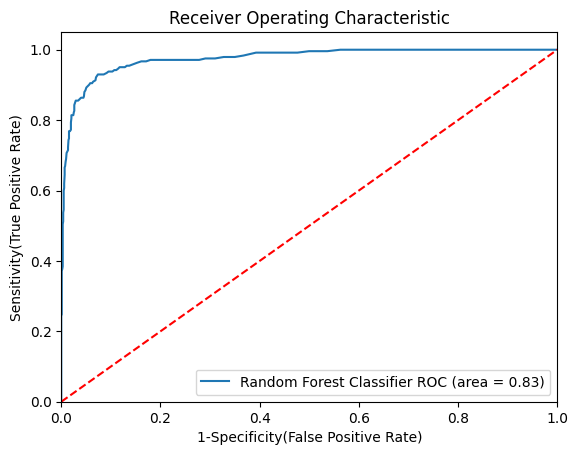

In [50]:
## Plot ROC AUC Curve
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt 
plt.figure()
auc_models=[
    {
 'label': 'Random Forest Classifier',
 'model': RandomForestClassifier(n_estimators=200, min_samples_split=2, max_features=7, max_depth= None),
 'auc' : 0.8325
    },
]

#Predict Prob gives probability of each class for each row
for algo in auc_models:
    model=algo['model']
    model.fit(X_train,y_train)
print(y_test)
print(model.predict_proba(X_test))

for algo in auc_models:
    model=algo['model']
    model.fit(X_train,y_train)
    fpr,tpr,thresholds=roc_curve(y_test,model.predict_proba(X_test)[:,1])
    plt.plot(fpr, tpr, label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc']))
# Custom settings for the plot 
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity(False Positive Rate)')
plt.ylabel('Sensitivity(True Positive Rate)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show() 


##### Multiclass ROC AUC curve

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
[[4.09968623e-03 8.12343852e-01 1.83556462e-01]
 [9.41955389e-01 5.80440306e-02 5.80205260e-07]
 [1.58411470e-08 2.09129590e-03 9.97908688e-01]
 [6.82490236e-03 7.73251430e-01 2.19923668e-01]
 [1.59400574e-03 7.51206007e-01 2.47199987e-01]
 [9.50040941e-01 4.99586002e-02 4.58820974e-07]
 [7.78025396e-02 9.04144994e-01 1.80524667e-02]
 [1.79836046e-04 1.47357798e-01 8.52462366e-01]
 [2.42255801e-03 7.80452547e-01 2.17124895e-01]
 [2.89983279e-02 9.40818577e-01 3.01830947e-02]
 [4.73570209e-04 2.25282341e-01 7.74244089e-01]
 [9.62693695e-01 3.73061213e-02 1.84138612e-07]
 [9.69162372e-01 3.08375314e-02 9.66512885e-08]
 [9.56006743e-01 4.39929912e-02 2.65383588e-07]
 [9.76521682e-01 2.347

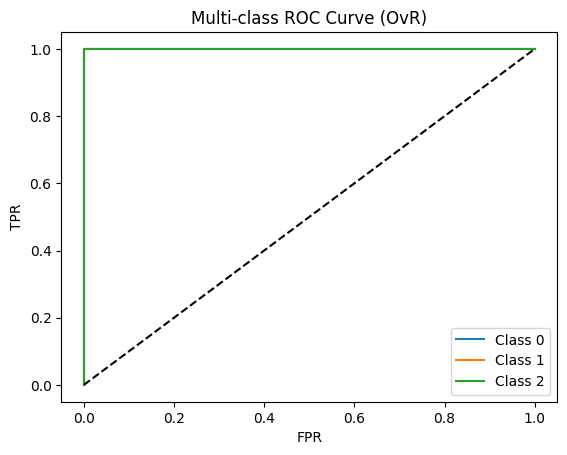

In [7]:
# Multiclass ROC AUC
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np

# Load dataset
X, y = load_iris(return_X_y=True)

# Binarize labels (needed for ROC)
y_bin = label_binarize(y, classes=[0, 1, 2])
print(y)
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.3, random_state=42)

# Train model
model = LogisticRegression()
# np.argmax(y_train, axis=1) --> it gives index where there is max in that way u get class eg [0,0,1]->2 as max is at 2
model.fit(X_train, np.argmax(y_train, axis=1))

# Predict probabilities
y_score = model.predict_proba(X_test)

print(y_score)
# Compute ROC-AUC (OvR)
auc = roc_auc_score(y_test, y_score, multi_class='ovr')
print("ROC-AUC (OvR):", auc)
import matplotlib.pyplot as plt

n_classes = y_test.shape[1]
print(n_classes)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1], [0,1], 'k--')  # random line
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("Multi-class ROC Curve (OvR)")
plt.legend()
plt.show()